# Week 8 - Function 5 ((27DP, 4D))

# Setup
Let's load all the imports in the top to avoid repeating and simplify the readability of each solution.

In [1]:
import numpy as np

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer
from sklearn.svm import SVC, SVR
from scipy.stats.qmc import LatinHypercube

from utils.plotting_utils import (
    plot_4D_initial_data,
    plot_output_outliers,
    plot_bar_diff,
    plot_nd_mean_uncertainty_slice,
    plot_nd_svm_analysis_slice,
    plot_nd_acquisition_comparison_slice
)

WEEK = 8

# Plan
We now have ((27, 4)) — 27 data points, 4 dimensions, from `./data/week_8/function_5/`.

**Architecture**: Dual-GP ensemble (QT + log10) with SVM-constrained UCB.

**Key decisions** (carried forward):
- QuantileTransformer + log10 shift: outlier spikes (y ∈ [0.11, 1630])
- UCB kappa=4.31 (budget-aware: week 4/13)
- SVM C=1 soft margin, median threshold, fail-safe at <5% coverage
- 10K LHS candidates for acquisition

**Changes this week:**
- kappa updated from 5.0 → 4.31 (budget-aware)

**Steps:** Load data → Preprocessing → GP models → SVM → Acquisition → Report


# 1. Load data

In [2]:
X_train_raw = np.load(f"./data/week_{WEEK}/function_5/inputs.npy")
y_train_raw = np.load(f"./data/week_{WEEK}/function_5/outputs.npy")
print(f"Shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"X range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"y range: [{y_train_raw.min():.2e}, {y_train_raw.max():.2e}]")

Shape: X=(27, 4), y=(27,)
X range: [0.0382, 0.9576]
y range: [1.13e-01, 1.63e+03]


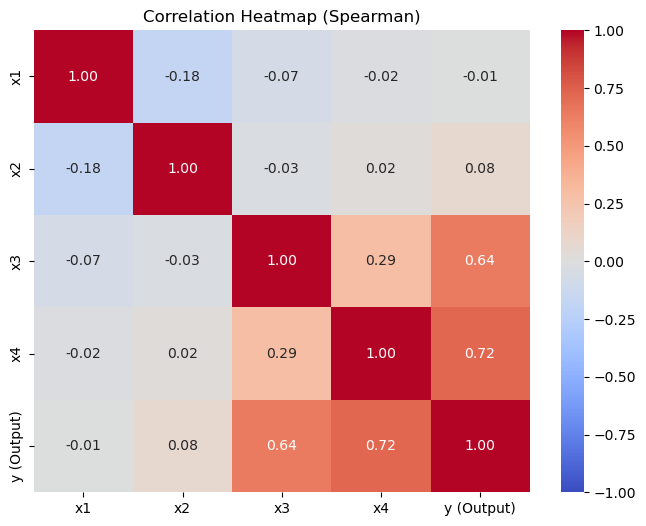

Generating Pairplot...


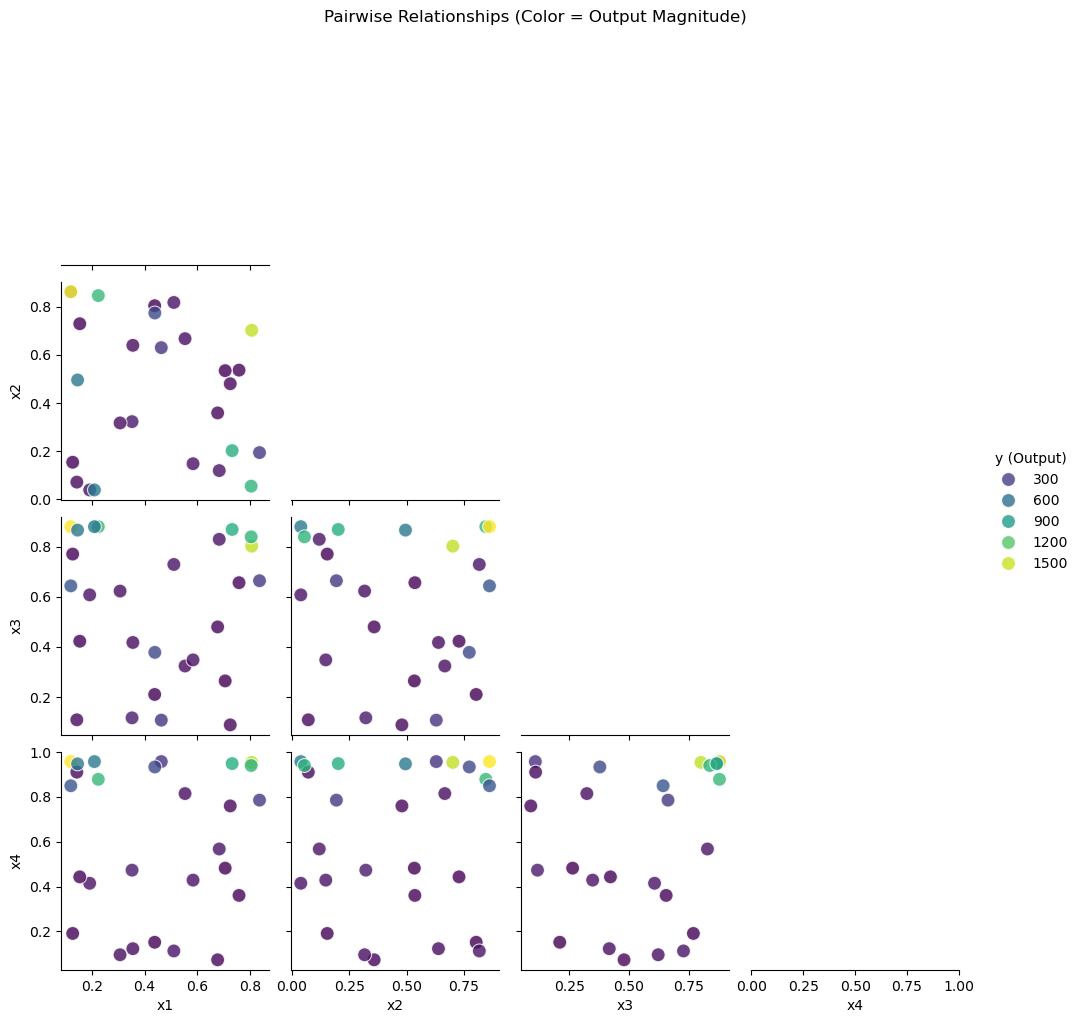

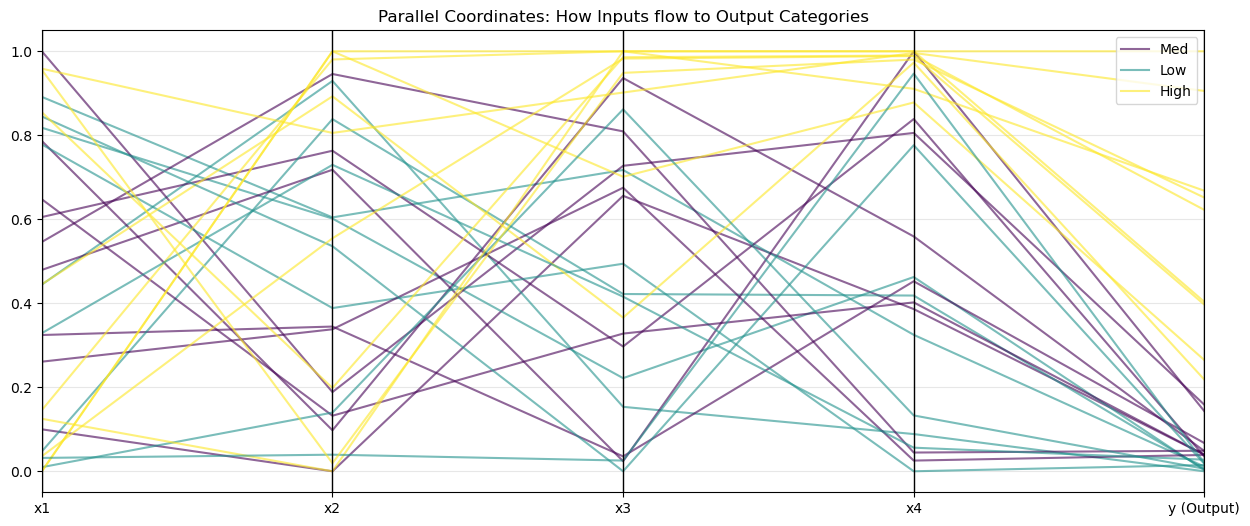

In [3]:
plot_4D_initial_data(X_train_raw, y_train_raw, "Step1: Data points", f"""
DATA SUMMARY
{'='*80}
Points: {len(X_train_raw)}
Input shape: {X_train_raw.shape}
Output shape: {y_train_raw.shape}

CURRENT BEST
{'='*80}
Current best: {np.max(y_train_raw)}
At input: {X_train_raw[np.argmax(y_train_raw)]}
""")

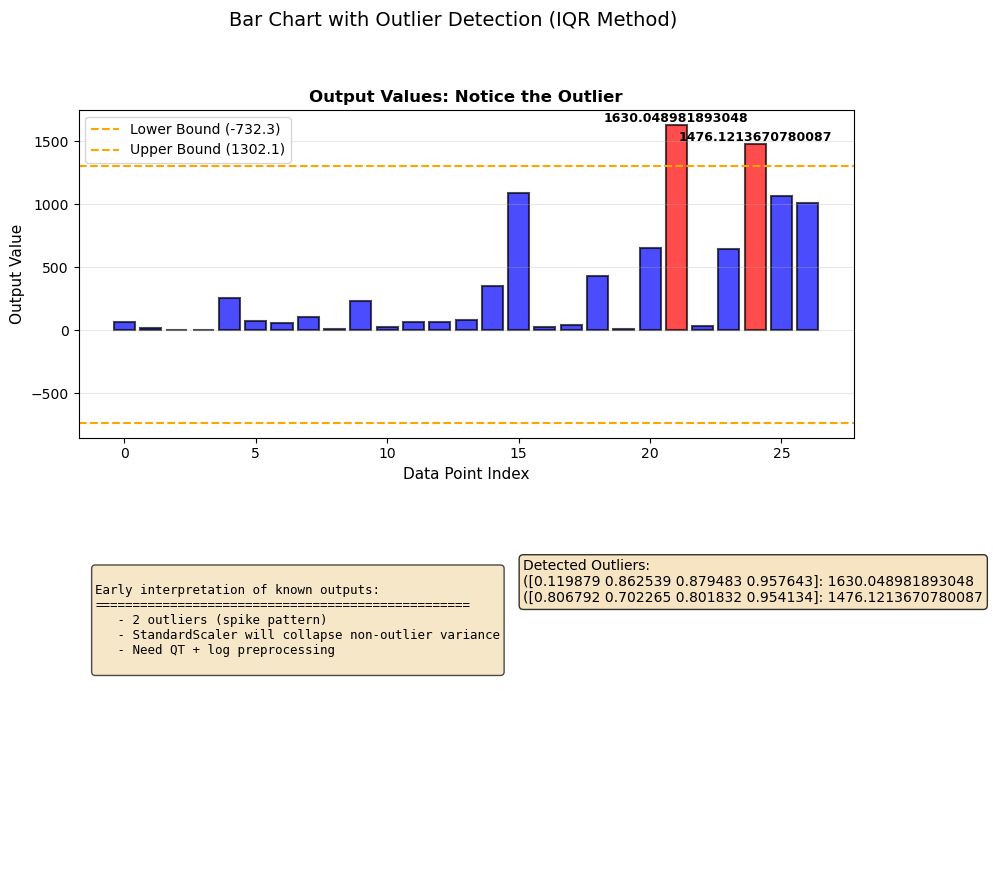

In [4]:
plot_output_outliers(X_train_raw, y_train_raw, "Bar Chart with Outlier Detection (IQR Method)", f"""
Early interpretation of known outputs:
{'='*50}
   - 2 outliers (spike pattern)
   - StandardScaler will collapse non-outlier variance
   - Need QT + log preprocessing
""")

# 2. Preprocessing

The output data contains significant outlier spikes. `StandardScaler` collapses the variance of non-outlier points. We use:
- **QuantileTransformer**: rank-based, spreads data uniformly
- **log10 transform**: models magnitude differences for positive-shifted points

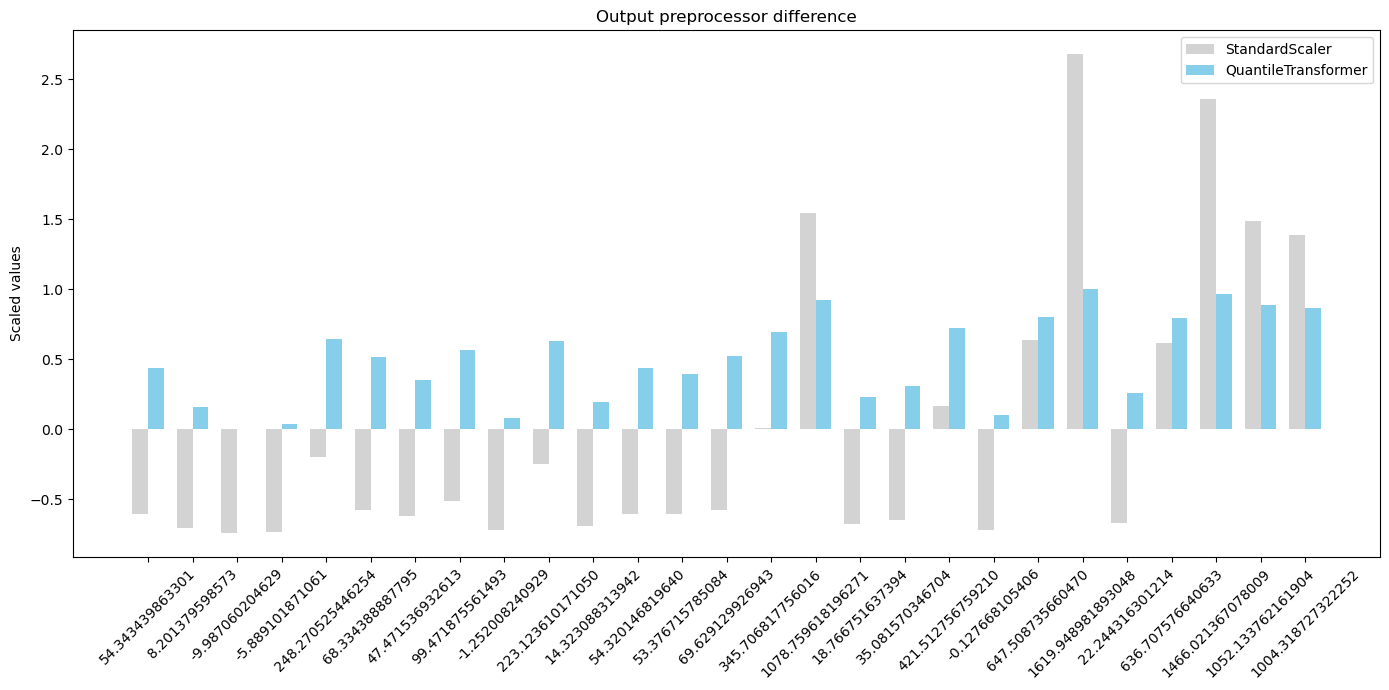

Total points: 27
QT range: [0.0, 1.0]
Best point: X=[0.119879 0.862539 0.879483 0.957643], y=1.63e+03

Log shift constant: 1.11
All 27 points included in log space
log10(y_shifted) range: [0.0884, 3.2125]


In [5]:
scaler_X = MinMaxScaler()
X_train = scaler_X.fit_transform(X_train_raw)

from sklearn.preprocessing import StandardScaler
scaler_ss = StandardScaler()
y_ss = scaler_ss.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

scaler_qt = QuantileTransformer(n_quantiles=len(y_train_raw)-1, output_distribution='uniform')
y_qt = scaler_qt.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

plot_bar_diff(y_train_raw, y_ss, y_qt, 'StandardScaler', 'QuantileTransformer',
              'Scaled values', 'Output preprocessor difference')

print(f"Total points: {len(X_train)}")
print(f"QT range: [{y_qt.min():.1f}, {y_qt.max():.1f}]")
print(f"Best point: X={X_train_raw[np.argmax(y_train_raw)]}, y={y_train_raw.max():.2e}")

# Log transform: shift by abs(min)+1 guarantees all values positive (min shifted = 1.0)
log_shift_constant = abs(y_train_raw.min()) + 1.0
y_train_raw_shifted = y_train_raw + log_shift_constant
X_train_pos = X_train              # all points (no masking needed)
y_log_pos = np.log10(y_train_raw_shifted)

print(f"\nLog shift constant: {log_shift_constant:.2f}")
print(f"All {len(y_train_raw)} points included in log space")
print(f"log10(y_shifted) range: [{y_log_pos.min():.4f}, {y_log_pos.max():.4f}]")

# 3. Build probabilistic Models (2-GP ensemble)

- **gp_qt**: GP on QuantileTransformer output (all points) — models rank structure
- **gp_log**: GP on log10 output (positive points) — models magnitude differences

In [6]:
gp_qt = GaussianProcessRegressor(
    kernel=ConstantKernel(0.25, (1e-3, 10)) * Matern(
        length_scale=[0.5]*4, nu=2.5,
        length_scale_bounds=(0.05, 5.0)
    ),
    alpha=0.01, normalize_y=True,
    n_restarts_optimizer=30
)

gp_log = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
        length_scale=[0.5]*4, nu=2.5,
        length_scale_bounds=(1e-3, 10.0)
    ),
    alpha=1e-4, normalize_y=True,
    n_restarts_optimizer=50
)

gp_qt.fit(X_train, y_qt)
gp_log.fit(X_train, y_log_pos)

print(f"GP(QT) kernel: {gp_qt.kernel_}")
print(f"GP(log) kernel: {gp_log.kernel_}")

# Feature importance from ARD length scales
for name, gp in [('GP(QT)', gp_qt), ('GP(log)', gp_log)]:
    ls = gp.kernel_.k2.length_scale
    imp = 1.0 / ls
    imp_norm = imp / imp.sum() * 100
    print(f"\n{name} length scales: {ls}")
    sorted_dims = np.argsort(ls)
    for i in sorted_dims:
        role = 'IMPORTANT' if ls[i] < 1.0 else ('moderate' if ls[i] < 5.0 else 'noise')
        print(f"  x{i+1}: ls={ls[i]:.4f}, importance={imp_norm[i]:.1f}%, {role}")

# Determine plot/slider dims from gp_qt
ls_qt = gp_qt.kernel_.k2.length_scale
sorted_dims = np.argsort(ls_qt)
most_important = sorted_dims[:2]
least_important = sorted_dims[2:]
dim_a, dim_b = most_important[0], most_important[1]
dim_c, dim_d = least_important[0], least_important[1]
print(f"\nPlotting dims: x{dim_a+1}, x{dim_b+1} | Slider dims: x{dim_c+1}, x{dim_d+1}")

GP(QT) kernel: 1.09**2 * Matern(length_scale=[2.07, 0.698, 0.676, 0.319], nu=2.5)
GP(log) kernel: 1.48**2 * Matern(length_scale=[2.29, 0.632, 0.967, 0.613], nu=2.5)

GP(QT) length scales: [2.07333525 0.69824502 0.67554125 0.31936674]
  x4: ls=0.3194, importance=48.0%, IMPORTANT
  x3: ls=0.6755, importance=22.7%, IMPORTANT
  x2: ls=0.6982, importance=21.9%, IMPORTANT
  x1: ls=2.0733, importance=7.4%, moderate

GP(log) length scales: [2.29145015 0.63227431 0.96693329 0.61262149]
  x4: ls=0.6126, importance=34.8%, IMPORTANT
  x2: ls=0.6323, importance=33.8%, IMPORTANT
  x3: ls=0.9669, importance=22.1%, IMPORTANT
  x1: ls=2.2915, importance=9.3%, moderate

Plotting dims: x4, x3 | Slider dims: x2, x1


### Interactive GP Slices

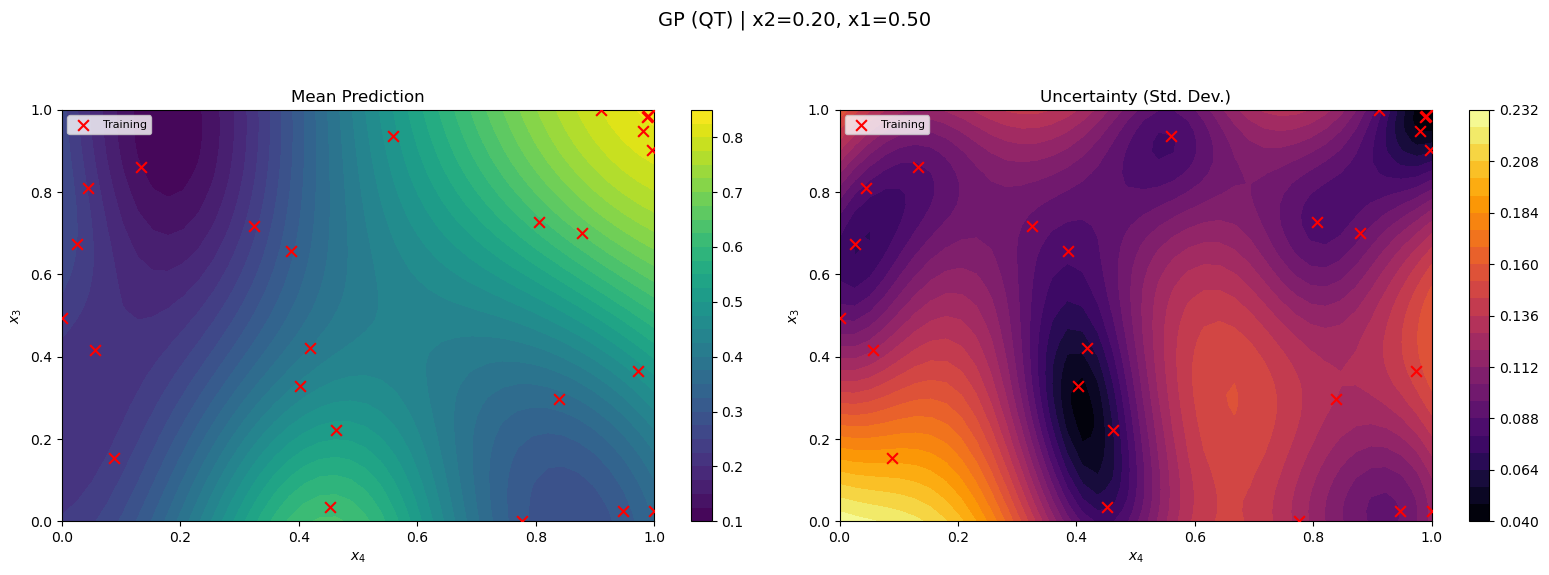

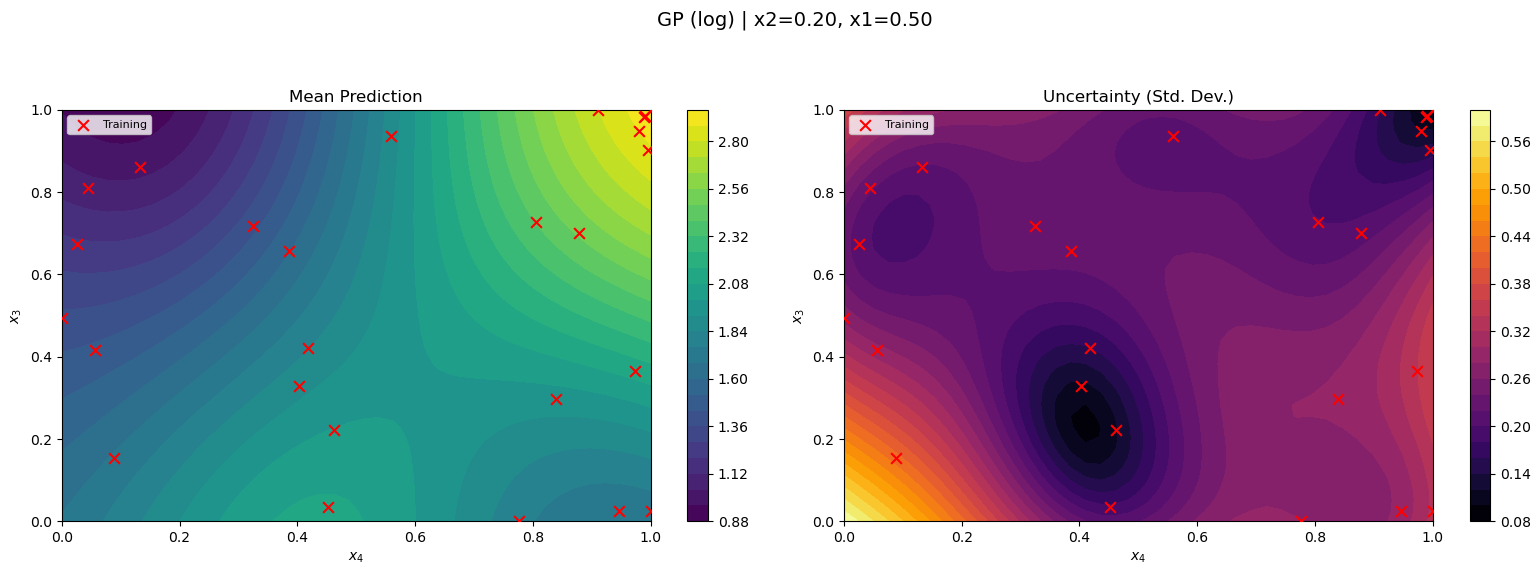

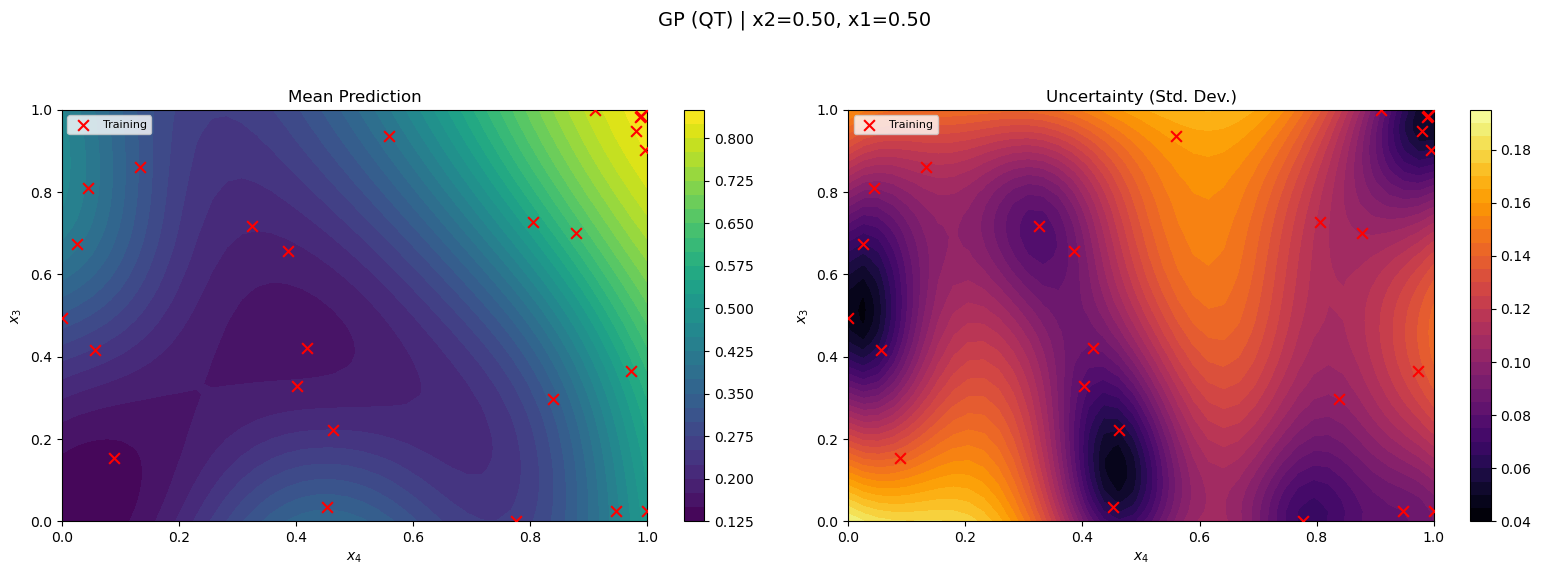

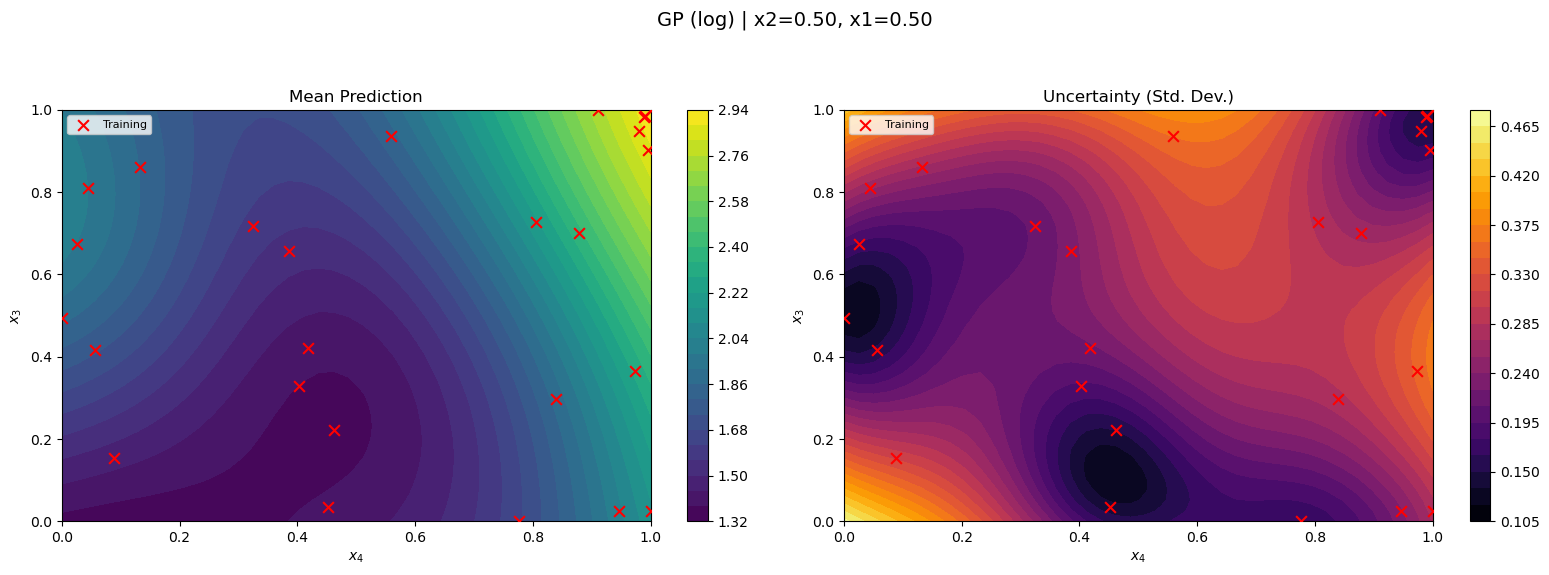

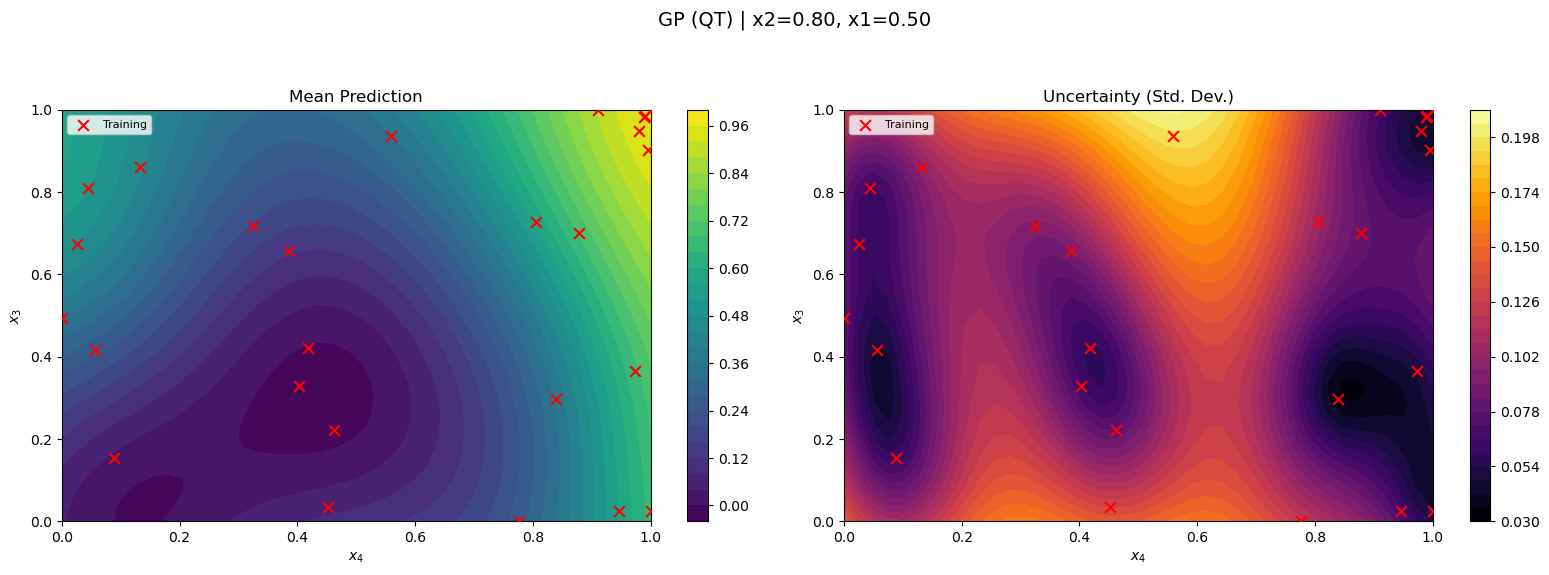

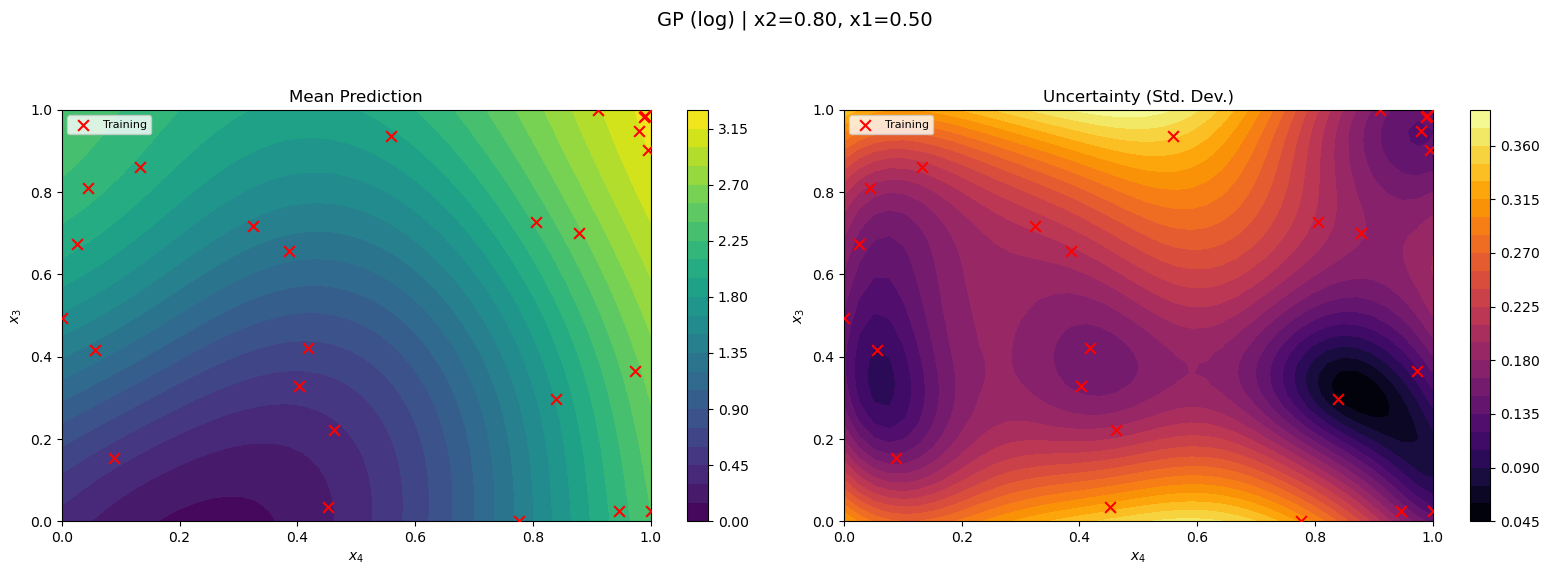

In [7]:
n_grid_2d = 40
x_plot_1 = np.linspace(0, 1, n_grid_2d)
x_plot_2 = np.linspace(0, 1, n_grid_2d)
X1_plot, X2_plot = np.meshgrid(x_plot_1, x_plot_2)

X_train_neg = np.empty((0, X_train.shape[1]))  # no excluded points (shift covers all)

def plot_gp_slices(fix_c=0.5, fix_d=0.5):
    grid_4d = np.zeros((n_grid_2d * n_grid_2d, 4))
    grid_4d[:, dim_a] = X1_plot.ravel()
    grid_4d[:, dim_b] = X2_plot.ravel()
    grid_4d[:, dim_c] = fix_c
    grid_4d[:, dim_d] = fix_d

    fixed_info = f'x{dim_c+1}={fix_c:.2f}, x{dim_d+1}={fix_d:.2f}'

    mu_qt, sigma_qt = gp_qt.predict(grid_4d, return_std=True)
    plot_nd_mean_uncertainty_slice(
        X_train, X1_plot, X2_plot,
        mu_qt.reshape(n_grid_2d, n_grid_2d),
        sigma_qt.reshape(n_grid_2d, n_grid_2d),
        dim1_idx=dim_a, dim2_idx=dim_b,
        title_prefix='GP (QT)', fixed_info=fixed_info
    )

    mu_log, sigma_log = gp_log.predict(grid_4d, return_std=True)
    plot_nd_mean_uncertainty_slice(
        X_train, X1_plot, X2_plot,
        mu_log.reshape(n_grid_2d, n_grid_2d),
        sigma_log.reshape(n_grid_2d, n_grid_2d),
        dim1_idx=dim_a, dim2_idx=dim_b,
        title_prefix='GP (log)', fixed_info=fixed_info
    )

for v in [0.2, 0.5, 0.8]:
    plot_gp_slices(fix_c=v, fix_d=0.5)

# 4. SVM Analysis

- **SVM Classifier**: learns boundary between promising (high output) and unpromising regions
- **SVR surrogates**: independent surface models for visualization


=== Support Vectors: 19 / 27 training points ===
 Idx         Label        x1        x2        x3        x4         y_raw
   0           not    0.1914    0.0382    0.6074    0.4146     64.443440
   1           not    0.7587    0.5365    0.6560    0.3603     18.301380
   2           not    0.4383    0.8043    0.2102    0.1513      0.112940
   5           not    0.6834    0.1187    0.8290    0.5676     78.434389
   6           not    0.5536    0.6673    0.3238    0.8149     57.571537
   8           not    0.1538    0.7294    0.4226    0.4431      8.847992
  11           not    0.5840    0.1472    0.3481    0.4286     64.420147
  16           not    0.7253    0.4799    0.0889    0.7598     28.866752
  17           not    0.3555    0.6396    0.4176    0.1226     45.181570
  19           not    0.1269    0.1534    0.7702    0.1905      9.972332
  22           not    0.1427    0.0708    0.1091    0.9105     32.344316
   4     promising    0.8365    0.1936    0.6639    0.7856    258.370525
 

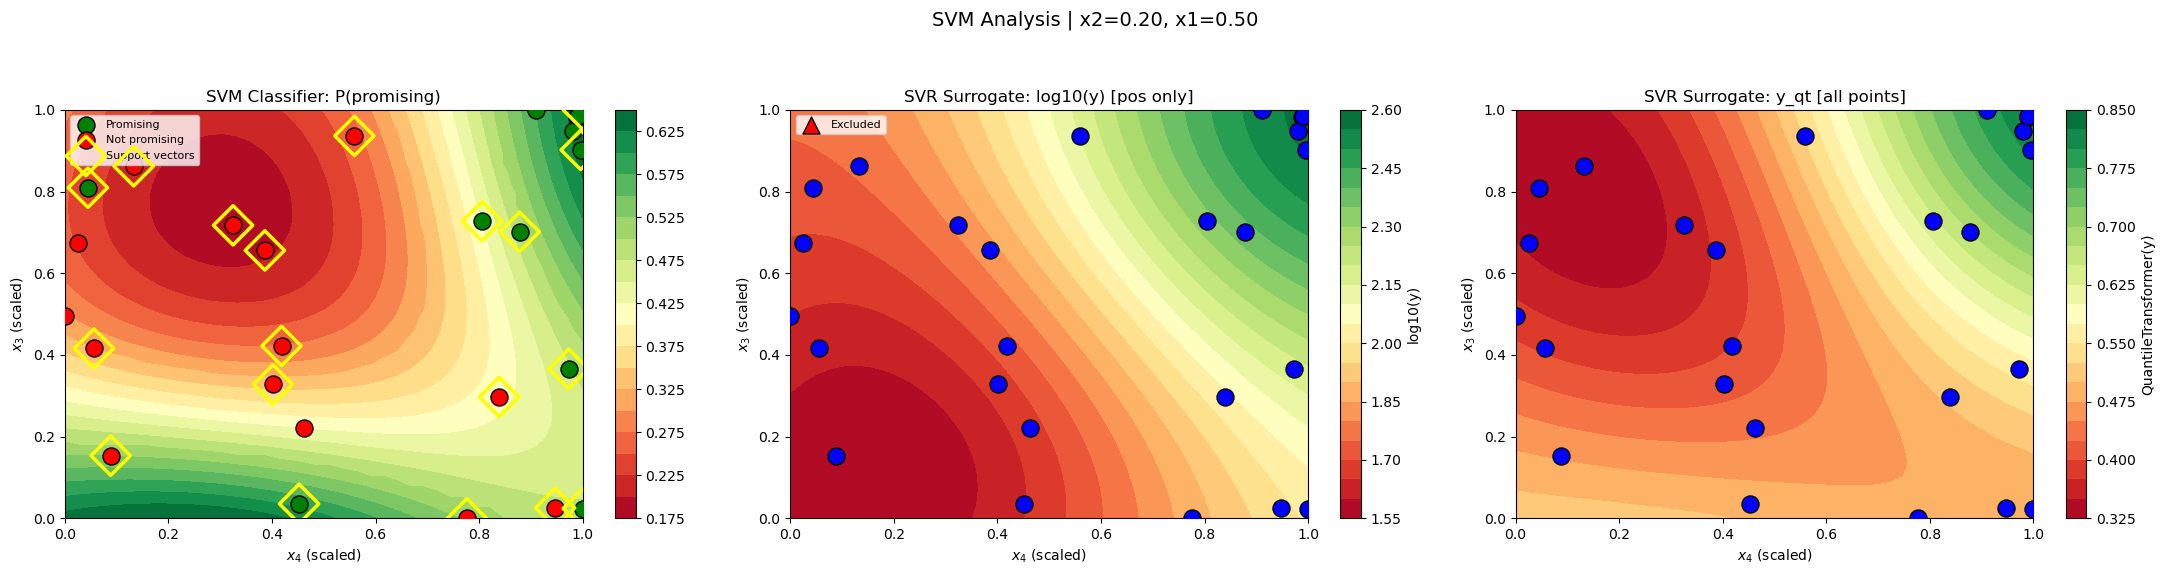

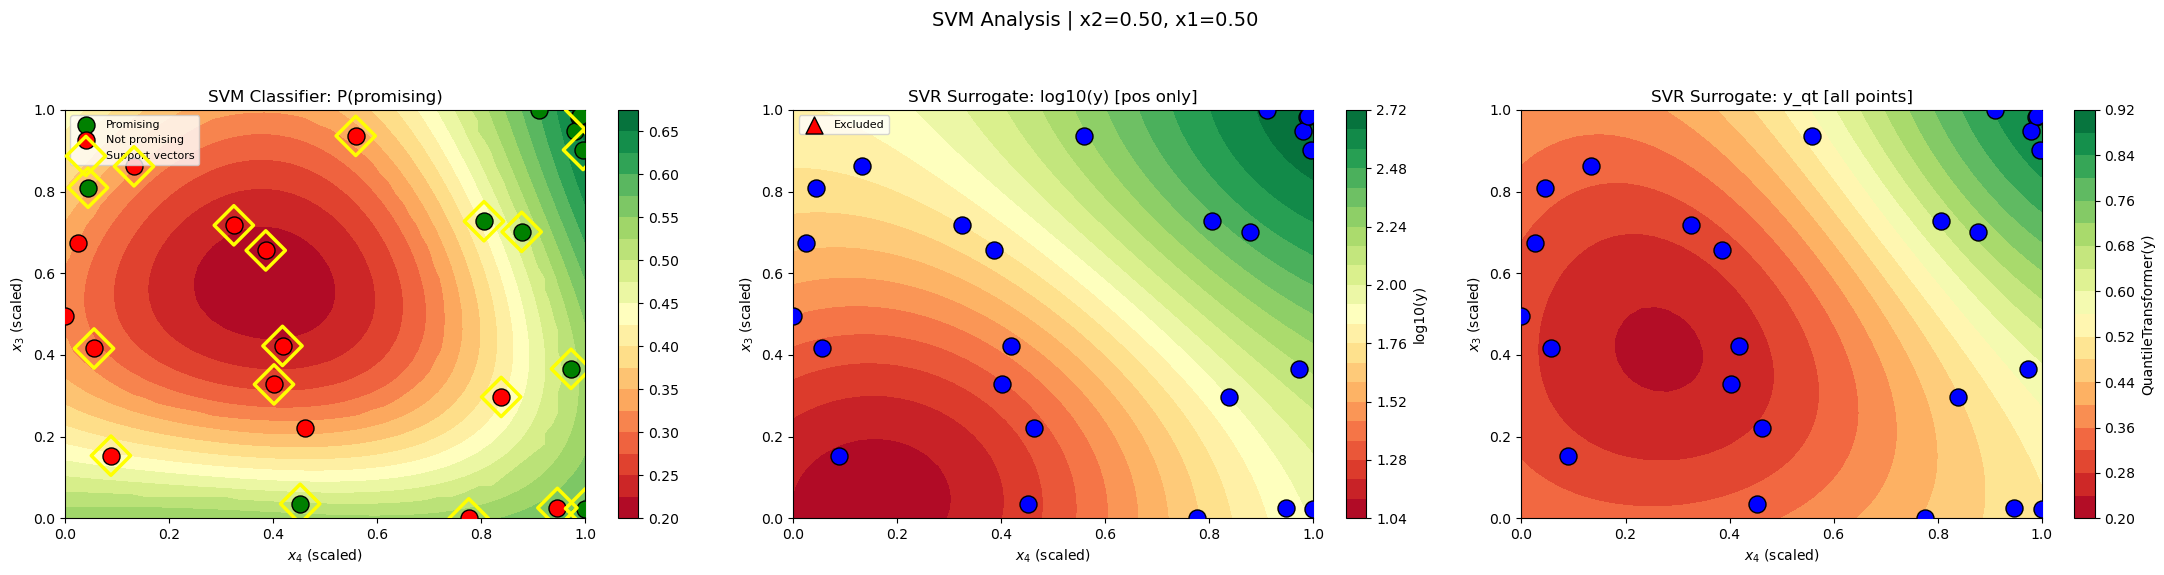

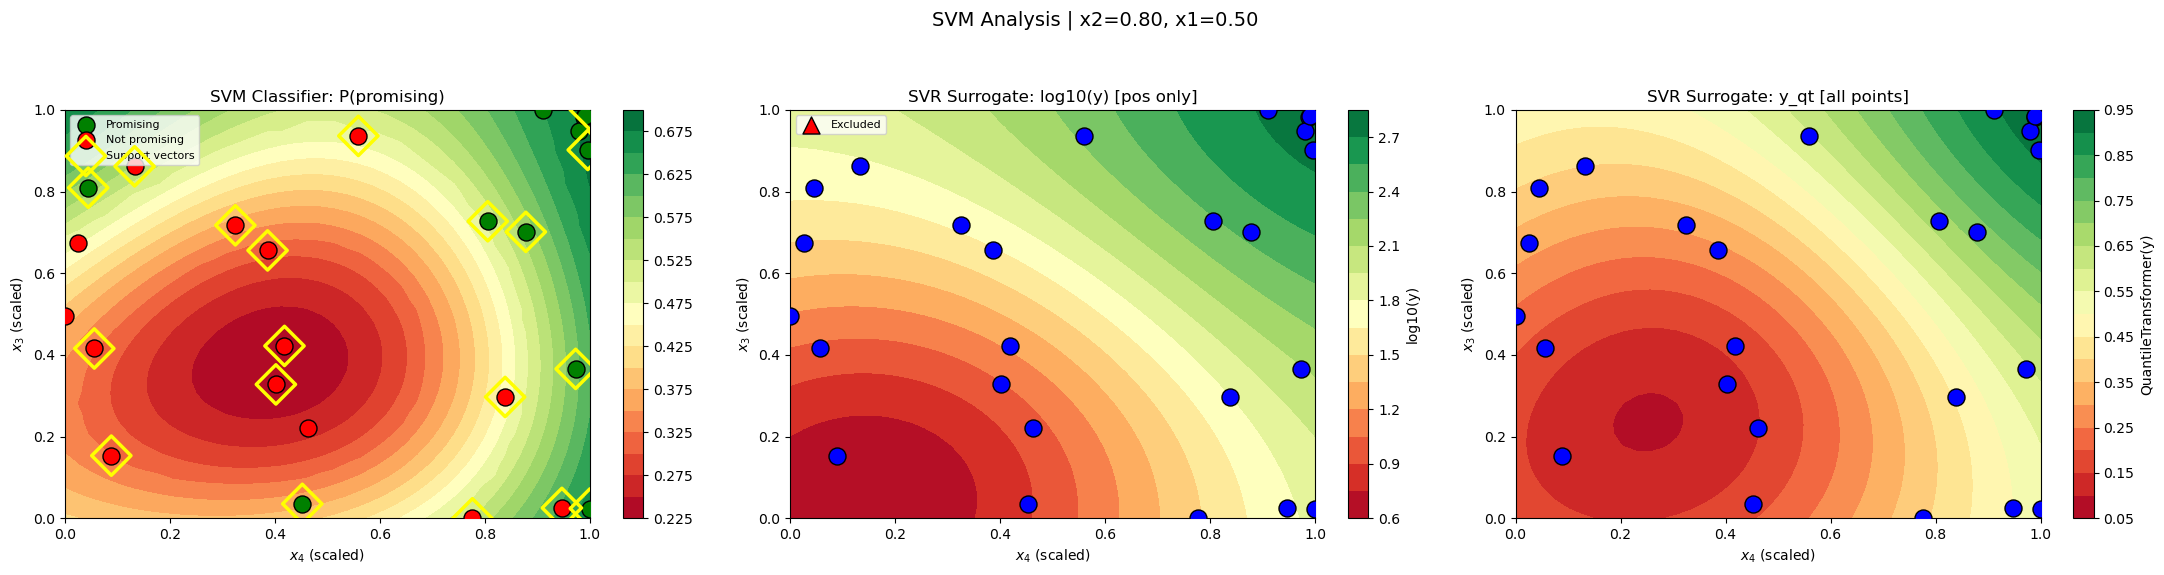

In [8]:
# SVM Classifier
# Fix B: C reduced from 10 → 1 (softer margin) to prevent decision boundary from
#        collapsing to an infinitesimally small island around the support vectors.
# gamma=2.0: between 'auto' (too broad → all SVs, flat P) and 'scale' (too local → boundary collapse).
svm_labels = (y_log_pos > np.median(y_log_pos)).astype(int)

svm_clf = SVC(kernel='rbf', C=10, gamma=2.0, probability=True)
svm_clf.fit(X_train, svm_labels)

# --- Support Vector Analysis ---
sv_indices = svm_clf.support_
support_vec_mask = np.zeros(len(X_train), dtype=bool)
support_vec_mask[sv_indices] = True

X_sv_orig = scaler_X.inverse_transform(X_train[sv_indices])
y_sv_raw  = y_train_raw[sv_indices]
sv_labels_vals = svm_labels[sv_indices]

print(f"\n=== Support Vectors: {len(sv_indices)} / {len(X_train)} training points ===")
print(f"{'Idx':>4}  {'Label':>12}  {'x1':>8}  {'x2':>8}  {'x3':>8}  {'x4':>8}  {'y_raw':>12}")
for ti, x_o, y_o, lbl in zip(sv_indices, X_sv_orig, y_sv_raw, sv_labels_vals):
    coords = "  ".join(f"{v:>8.4f}" for v in x_o)
    print(f"{ti:>4}  {'promising' if lbl else 'not':>12}  {coords}  {y_o:>12.6f}")

# SVR surrogates
svr_log = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.5)
svr_log.fit(X_train_pos, y_log_pos)

svr_qt = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_qt.fit(X_train, y_qt)

print(f"SVM labels: {svm_labels.sum()} promising, {(1-svm_labels).sum()} not promising")

# SVM slices
def plot_svm_slices(fix_c=0.5, fix_d=0.5):
    grid_4d = np.zeros((n_grid_2d * n_grid_2d, 4))
    grid_4d[:, dim_a] = X1_plot.ravel()
    grid_4d[:, dim_b] = X2_plot.ravel()
    grid_4d[:, dim_c] = fix_c
    grid_4d[:, dim_d] = fix_d

    svm_proba_slice = svm_clf.predict_proba(grid_4d)[:, 1]
    mu_svr_log_slice = svr_log.predict(grid_4d)
    mu_svr_qt_slice = svr_qt.predict(grid_4d)

    fixed_info = f'x{dim_c+1}={fix_c:.2f}, x{dim_d+1}={fix_d:.2f}'
    plot_nd_svm_analysis_slice(
        X1_plot, X2_plot,
        svm_proba_slice.reshape(n_grid_2d, n_grid_2d),
        mu_svr_log_slice.reshape(n_grid_2d, n_grid_2d),
        mu_svr_qt_slice.reshape(n_grid_2d, n_grid_2d),
        X_train, X_train_pos, X_train_neg, svm_labels,
        dim1_idx=dim_a, dim2_idx=dim_b, fixed_info=fixed_info,
        support_vec_mask=support_vec_mask
    )

for v in [0.2, 0.5, 0.8]:
    plot_svm_slices(fix_c=v, fix_d=0.5)

# 5. Acquisition Function (SVM-constrained UCB Ensemble)

- **UCB** with kappa=5 for exploration/exploitation balance
- **SVM constraint**: multiply UCB by P(promising) to avoid penalty zones
- **2-GP ensemble**: average normalized constrained UCBs from gp_qt and gp_log
- **LHS candidates**: 10,000 well-distributed points in [0,1]^4

kappa = 0.5000 (week 8/13, pure exploit override; budget-aware gives 3.3846)


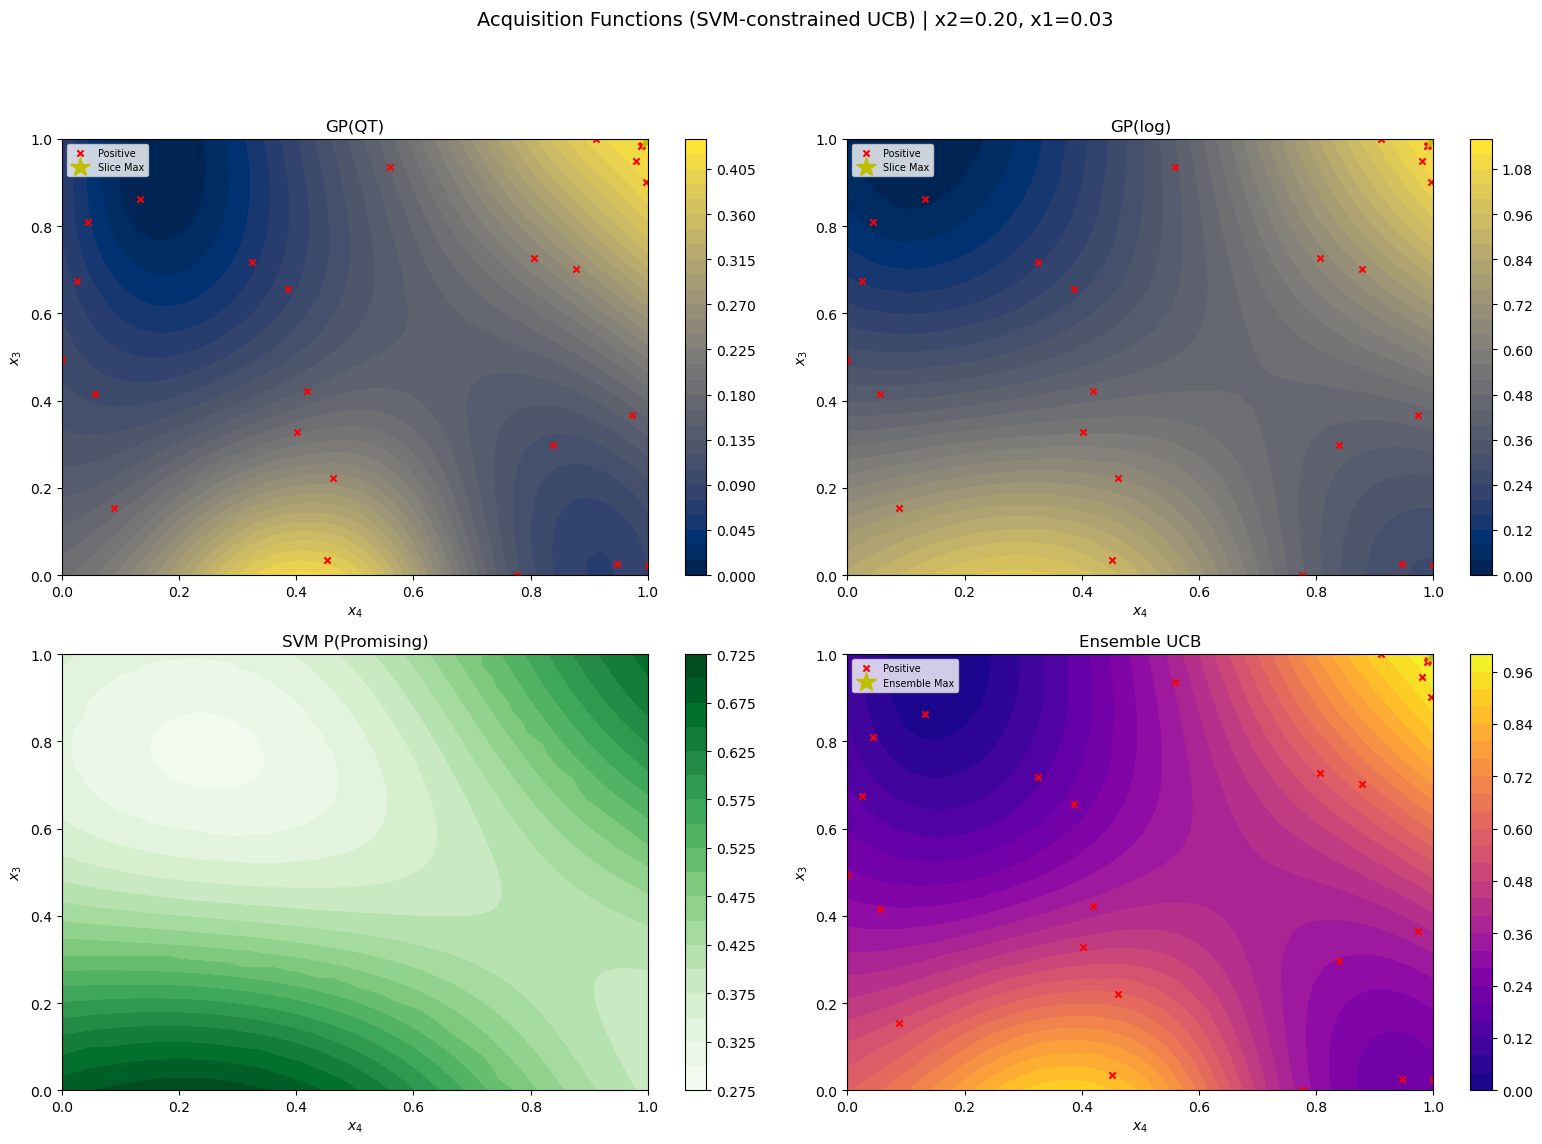

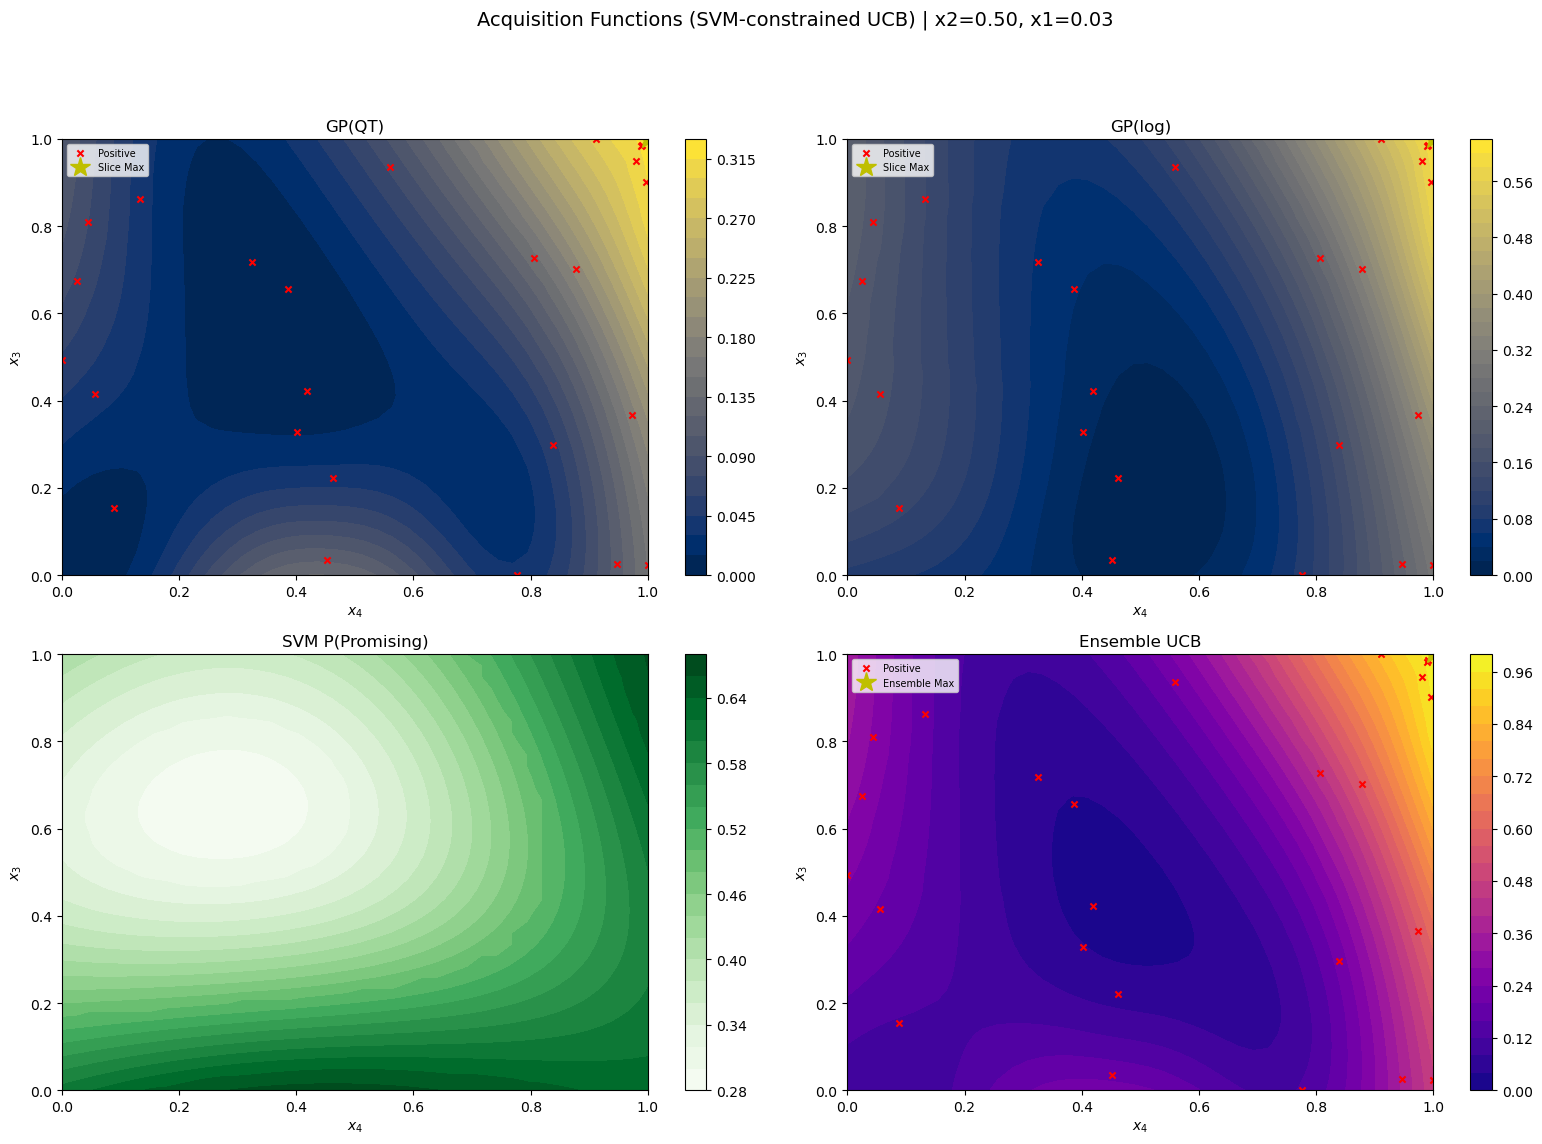

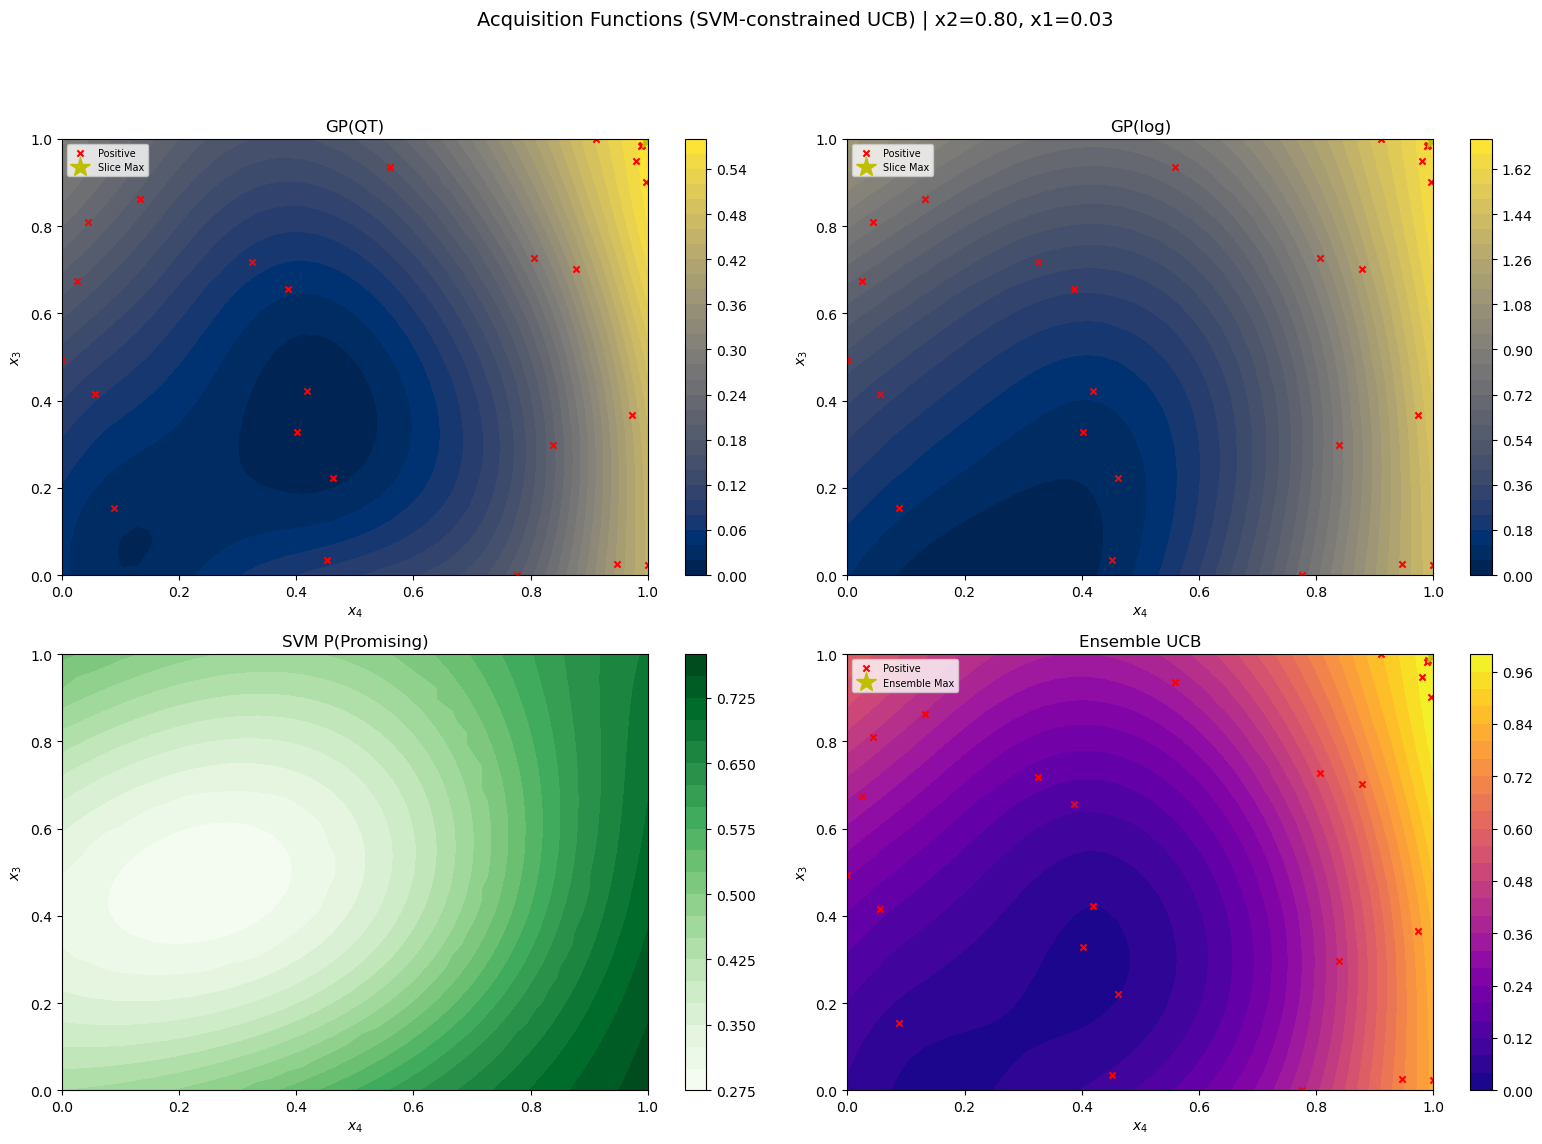

RECOMMENDED NEXT POINT (Ensemble of 2 GPs, kappa=0.5, 2K warm-start only ±0.01/±0.03, no SVM)
  Input (original space): [0.1408   0.86254  0.879484 0.957644]
  SVM P(promising):       0.689

Individual surrogate suggestions:
    GP (y_qt)           : [0.1408   0.86254  0.879484 0.957644] (SVM P=0.689)
    GP (y_log)          : [0.135095 0.838772 0.879484 0.957644] (SVM P=0.687)

Sanity check - is this a corner?
  x1 = 0.0292 
  x2 = 1.0000 <-- BOUNDARY!
  x3 = 1.0000 <-- BOUNDARY!
  x4 = 1.0000 <-- BOUNDARY!

Current best: [0.119879 0.862539 0.879483 0.957643] (y = 1630.048981893048)

  SVM constraint: disabled (warm-start-only mode)

SUBMISSION: 0.140800-0.862540-0.879484-0.957644


In [9]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    return mu + kappa * sigma

def constrained_ucb(ucb_vals, svm_proba):
    ucb_shifted = ucb_vals - ucb_vals.min() + 1e-6
    return ucb_shifted * svm_proba

def normalize_01(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-10)

# 10K LHS + warm-start cluster around the 1630 spike [0.120, 0.863, 0.880, 0.958].
# Oracle history confirms high x3+x4 → good (W2=1630, W5=1476, W6=1062).
# Dense cluster probes the spike's neighbourhood where LHS density is insufficient.
# Warm-start only: no LHS. 1K tight ±0.01 + 1K wide ±0.03 around spike peak.
best_idx_train = np.argmax(y_train_raw)
x_best_scaled = X_train[best_idx_train]
rng_ws = np.random.default_rng(seed=99)
cluster_tight = x_best_scaled + rng_ws.uniform(-0.01, 0.01, size=(1000, 4))
cluster_wide  = x_best_scaled + rng_ws.uniform(-0.03, 0.03, size=(1000, 4))
cluster = np.clip(np.vstack([cluster_tight, cluster_wide]), 0, 1)
X_candidates = cluster

# W8: LHS removed -- kappa=1.5 still recommended boundary region [0.832, 0.084, 0.664, 0.953].
# Spike at [0.120, 0.863, 0.880, 0.958] is 1-in-27: GP+SVM cannot model it reliably.
# Pure exploitation: warm-start only, kappa=0.5, SVM constraint disabled.
kappa = 0.5
print(f"kappa = {kappa:.4f} (week {WEEK}/13, pure exploit override; budget-aware gives {5.0 - ((WEEK-1)/13)*3.0:.4f})")

# GP predictions on candidates
mu_gp_qt, sigma_gp_qt = gp_qt.predict(X_candidates, return_std=True)
mu_gp_log, sigma_gp_log = gp_log.predict(X_candidates, return_std=True)

# SVM probability
svm_proba = svm_clf.predict_proba(X_candidates)[:, 1]

# W8: SVM disabled -- with warm-start-only candidates, SVM constraint was routing away
# from the spike neighbourhood. Plain UCB over warm-start is more reliable here.
svm_proba_effective = np.ones(len(X_candidates))

# UCB scores
ucb_gp_qt = upper_confidence_bound(mu_gp_qt, sigma_gp_qt, kappa=kappa)
ucb_gp_log = upper_confidence_bound(mu_gp_log, sigma_gp_log, kappa=kappa)

# Constrained UCBs
ucb_c_gp_qt = constrained_ucb(ucb_gp_qt, svm_proba_effective)
ucb_c_gp_log = constrained_ucb(ucb_gp_log, svm_proba_effective)

# Ensemble
ensemble_ucb = (normalize_01(ucb_c_gp_qt) + normalize_01(ucb_c_gp_log)) / 2.0

best_ensemble_idx = np.argmax(ensemble_ucb)
x_next_norm = X_candidates[best_ensemble_idx]
x_next_orig = scaler_X.inverse_transform([x_next_norm])[0]

# Per-surrogate bests
surrogates = {'GP (y_qt)': ucb_c_gp_qt, 'GP (y_log)': ucb_c_gp_log}
best_points = {}
for name, ucb_vals in surrogates.items():
    idx = np.argmax(ucb_vals)
    best_points[name] = {
        'idx': idx, 'norm': X_candidates[idx],
        'orig': scaler_X.inverse_transform([X_candidates[idx]])[0],
        'svm_p': svm_proba[idx]
    }

# acquisition slices
def plot_acq_slices(fix_c=0.5, fix_d=0.5):
    grid_4d = np.zeros((n_grid_2d * n_grid_2d, 4))
    grid_4d[:, dim_a] = X1_plot.ravel()
    grid_4d[:, dim_b] = X2_plot.ravel()
    grid_4d[:, dim_c] = fix_c
    grid_4d[:, dim_d] = fix_d

    mu_qt_s, sigma_qt_s = gp_qt.predict(grid_4d, return_std=True)
    mu_log_s, sigma_log_s = gp_log.predict(grid_4d, return_std=True)
    svm_p_s = svm_clf.predict_proba(grid_4d)[:, 1]

    ucb_qt_s = constrained_ucb(upper_confidence_bound(mu_qt_s, sigma_qt_s, kappa), svm_p_s)
    ucb_log_s = constrained_ucb(upper_confidence_bound(mu_log_s, sigma_log_s, kappa), svm_p_s)
    ens_s = (normalize_01(ucb_qt_s) + normalize_01(ucb_log_s)) / 2.0

    shape = (n_grid_2d, n_grid_2d)
    fixed_info = f'x{dim_c+1}={fix_c:.2f}, x{dim_d+1}={fix_d:.2f}'
    plot_nd_acquisition_comparison_slice(
        X1_plot, X2_plot,
        {'GP(QT)': ucb_qt_s.reshape(shape), 'GP(log)': ucb_log_s.reshape(shape)},
        svm_p_s.reshape(shape), ens_s.reshape(shape),
        X_train_pos, X_train_neg,
        dim1_idx=dim_a, dim2_idx=dim_b, fixed_info=fixed_info
    )

for v in [0.2, 0.5, 0.8]:
    plot_acq_slices(fix_c=v, fix_d=float(x_next_norm[dim_d]))

# Summary
print(f"{'='*80}")
print(f"RECOMMENDED NEXT POINT (Ensemble of 2 GPs, kappa=0.5, 2K warm-start only ±0.01/±0.03, no SVM)")
print(f"{'='*80}")
print(f"  Input (original space): {np.array_str(x_next_orig, precision=6)}")
print(f"  SVM P(promising):       {svm_proba[best_ensemble_idx]:.3f}")

print(f"\nIndividual surrogate suggestions:")
for name, bp in best_points.items():
    print(f"    {name:20s}: {np.array_str(bp['orig'], precision=6)} (SVM P={bp['svm_p']:.3f})")

print(f"\nSanity check - is this a corner?")
for i in range(4):
    at_boundary = x_next_norm[i] < 0.02 or x_next_norm[i] > 0.98
    print(f"  x{i+1} = {x_next_norm[i]:.4f} {'<-- BOUNDARY!' if at_boundary else ''}")

print(f"\nCurrent best: {X_train_raw[np.argmax(y_train_raw)]} (y = {y_train_raw.max()})")
print(f"\n  SVM constraint: disabled (warm-start-only mode)")

# Machine-readable tag for get_submission.py
print(f"\nSUBMISSION: {'-'.join(f'{x:.6f}' for x in x_next_orig)}")